# COVID-19 Global Data Analysis
**Author:** Suryansh Chaurasia &nbsp;|&nbsp; **Dataset:** Johns Hopkins CSSE (Jan 2020 – May 2021)

---

## Project Overview

In early 2020, COVID-19 spread from a single city in China to every corner of the world in a matter of weeks. This project uses the Johns Hopkins CSSE dataset — one of the most comprehensive public records of the pandemic — to answer a series of questions:

- Which countries were hit hardest, and when?
- How did China's outbreak evolve at the provincial level?
- Did Germany, France, and Italy experience their worst surges at the same time?
- How did death rates and recovery rates differ across countries and over time?

The analysis covers **confirmed cases, deaths, and recoveries** across 180+ countries from **January 2020 to May 2021**.

---

## Table of Contents
1. [Data Loading & Inspection](#section1)
2. [Data Cleaning & Reshaping](#section2)
3. [Merging the Datasets](#section3)
4. [Global Trends — Top 5 Countries](#section4)
5. [China: A Provincial Breakdown](#section5)
6. [Europe: Peak Surge Analysis](#section6)
7. [Recovery Rates — Canada vs Australia](#section7)
8. [Death Rates by Province — Canada](#section8)
9. [Deaths Over Time — United States](#section9)
10. [Monthly Trends — US, Italy, Brazil, India](#section10)
11. [Highest Death Rates in 2020](#section11)
12. [South Africa — Recoveries vs Deaths](#section12)
13. [Recovery Ratios — US vs India](#section13)
14. [Key Findings & Conclusions](#section14)


In [1]:
import pandas as pd
confirmed_cases = pd.read_csv("covid_19_confirmed.csv")
confirmed_cases.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,13569,13569,13569,13569,13569,13664,13671,13682,13693,13693
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,31661,31909,32149,32441,32623,32933,33338,33607,33944,34180


---
## 1. Data Loading & Inspection <a id='section1'></a>

The Johns Hopkins dataset comes in three separate CSV files — one each for confirmed cases, deaths, and recovered cases. Each file uses a **wide format**: rows represent locations (country/province) and columns represent individual dates.

We load all three files and inspect their shape and structure before any transformation.

In [2]:
confirmed_cases.shape

(276, 498)

In [3]:
deaths_cases = pd.read_csv("covid_19_deaths.csv")
deaths_cases.head()

,Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,...,Column489,Column490,Column491,Column492,Column493,Column494,Column495,Column496,Column497,Column498
0,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
1,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
2,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449
3,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,3401,3405,3411,3418,3426,3433,3440,3448,3455,3460
4,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,127,127,127,127,127,127,127,127,127,127


> **Note on the deaths CSV:** The first row contains metadata rather than column names. We use `header=1` to promote the correct row as the header — skipping the orphaned first row.

In [4]:
# Promoting the Headers
deaths_cases = pd.read_csv("covid_19_deaths.csv" , header = 1)
deaths_cases.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,3401,3405,3411,3418,3426,3433,3440,3448,3455,3460
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,127,127,127,127,127,127,127,127,127,127
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,704,709,715,725,731,735,742,745,749,757


In [5]:
deaths_cases.shape

(276, 498)

> **Note on the recovered CSV:** Here the column names are stored inside row 0 of the data itself. We manually assign that row as the column header, then drop it from the DataFrame.

In [6]:
# Promoting the Headers
# recovered_cases = pd.read_csv("covid_19_recovered.csv" , header = 1)
recovered_cases = pd.read_csv("covid_19_recovered.csv")
recovered_cases.head()

,Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,...,Column489,Column490,Column491,Column492,Column493,Column494,Column495,Column496,Column497,Column498
0,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
1,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
2,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215
3,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,87902,88066,88208,88346,88497,88672,88861,89040,89232,89419
4,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,13234,13234,13234,13234,13234,13263,13381,13405,13416,13416


In [7]:
recovered_cases.shape

(262, 498)

In [8]:
recovered_cases.columns

Index(['Column1', 'Column2', 'Column3', 'Column4', 'Column5', 'Column6',
       'Column7', 'Column8', 'Column9', 'Column10',
       ...
       'Column489', 'Column490', 'Column491', 'Column492', 'Column493',
       'Column494', 'Column495', 'Column496', 'Column497', 'Column498'],
      dtype='object', length=498)

In [9]:
recovered_cases.iloc[0]

Column1      Province/State
Column2      Country/Region
Column3                 Lat
Column4                Long
Column5             1/22/20
                  ...      
Column494           5/25/21
Column495           5/26/21
Column496           5/27/21
Column497           5/28/21
Column498           5/29/21
Name: 0, Length: 498, dtype: object

In [10]:
recovered_cases.columns = recovered_cases.iloc[0]
recovered_cases = recovered_cases.drop(0).reset_index(drop = True)
recovered_cases.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,87902,88066,88208,88346,88497,88672,88861,89040,89232,89419
3,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,13234,13234,13234,13234,13234,13263,13381,13405,13416,13416
4,NaN,Angola,-11.2027,17.8739,0,0,0,0,0,0,...,26483,26513,26775,26778,27087,27204,27467,27529,27577,27646


---
## 2. Data Cleaning & Reshaping <a id='section2'></a>

### Why reshape from wide to long?

Each CSV currently has one row per location and one **column per date** — over 400 date columns. This 'wide' format is hard to filter, group, and visualise. We use `pandas.melt()` to **unpivot** the date columns into a single `Date` column, producing a clean long-format table where each row represents one location on one day.

```
Wide format (before melt):
Country | Province | 1/22/20 | 1/23/20 | ...
US      | New York | 0       | 1       | ...

Long format (after melt):
Country | Province | Date       | Confirmed
US      | New York | 2020-01-22 | 0
US      | New York | 2020-01-23 | 1
```

In [11]:
all_cols = confirmed_cases.columns
all_cols

Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '5/20/21', '5/21/21', '5/22/21', '5/23/21', '5/24/21', '5/25/21',
       '5/26/21', '5/27/21', '5/28/21', '5/29/21'],
      dtype='object', length=498)

In [12]:
date_cols = confirmed_cases.iloc[:,4:].columns
date_cols

Index(['1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       '1/28/20', '1/29/20', '1/30/20', '1/31/20',
       ...
       '5/20/21', '5/21/21', '5/22/21', '5/23/21', '5/24/21', '5/25/21',
       '5/26/21', '5/27/21', '5/28/21', '5/29/21'],
      dtype='object', length=494)

In [13]:
# pandas.melt(frame, id_vars=None, value_vars=None, var_name=None, value_name='value')
id_vars = ['Province/State', 'Country/Region', 'Lat', 'Long']
date_cols = [c for c in all_cols if c not in id_vars] # List Comprehension
date_cols

['1/22/20',
 '1/23/20',
 '1/24/20',
 '1/25/20',
 '1/26/20',
 '1/27/20',
 '1/28/20',
 '1/29/20',
 '1/30/20',
 '1/31/20',
 '2/1/20',
 '2/2/20',
 '2/3/20',
 '2/4/20',
 '2/5/20',
 '2/6/20',
 '2/7/20',
 '2/8/20',
 '2/9/20',
 '2/10/20',
 '2/11/20',
 '2/12/20',
 '2/13/20',
 '2/14/20',
 '2/15/20',
 '2/16/20',
 '2/17/20',
 '2/18/20',
 '2/19/20',
 '2/20/20',
 '2/21/20',
 '2/22/20',
 '2/23/20',
 '2/24/20',
 '2/25/20',
 '2/26/20',
 '2/27/20',
 '2/28/20',
 '2/29/20',
 '3/1/20',
 '3/2/20',
 '3/3/20',
 '3/4/20',
 '3/5/20',
 '3/6/20',
 '3/7/20',
 '3/8/20',
 '3/9/20',
 '3/10/20',
 '3/11/20',
 '3/12/20',
 '3/13/20',
 '3/14/20',
 '3/15/20',
 '3/16/20',
 '3/17/20',
 '3/18/20',
 '3/19/20',
 '3/20/20',
 '3/21/20',
 '3/22/20',
 '3/23/20',
 '3/24/20',
 '3/25/20',
 '3/26/20',
 '3/27/20',
 '3/28/20',
 '3/29/20',
 '3/30/20',
 '3/31/20',
 '4/1/20',
 '4/2/20',
 '4/3/20',
 '4/4/20',
 '4/5/20',
 '4/6/20',
 '4/7/20',
 '4/8/20',
 '4/9/20',
 '4/10/20',
 '4/11/20',
 '4/12/20',
 '4/13/20',
 '4/14/20',
 '4/15/20',
 '4/16/

In [14]:
date_cols = []
for c in all_cols:
    if c not in id_vars:
        date_cols.append(c)
date_cols

['1/22/20',
 '1/23/20',
 '1/24/20',
 '1/25/20',
 '1/26/20',
 '1/27/20',
 '1/28/20',
 '1/29/20',
 '1/30/20',
 '1/31/20',
 '2/1/20',
 '2/2/20',
 '2/3/20',
 '2/4/20',
 '2/5/20',
 '2/6/20',
 '2/7/20',
 '2/8/20',
 '2/9/20',
 '2/10/20',
 '2/11/20',
 '2/12/20',
 '2/13/20',
 '2/14/20',
 '2/15/20',
 '2/16/20',
 '2/17/20',
 '2/18/20',
 '2/19/20',
 '2/20/20',
 '2/21/20',
 '2/22/20',
 '2/23/20',
 '2/24/20',
 '2/25/20',
 '2/26/20',
 '2/27/20',
 '2/28/20',
 '2/29/20',
 '3/1/20',
 '3/2/20',
 '3/3/20',
 '3/4/20',
 '3/5/20',
 '3/6/20',
 '3/7/20',
 '3/8/20',
 '3/9/20',
 '3/10/20',
 '3/11/20',
 '3/12/20',
 '3/13/20',
 '3/14/20',
 '3/15/20',
 '3/16/20',
 '3/17/20',
 '3/18/20',
 '3/19/20',
 '3/20/20',
 '3/21/20',
 '3/22/20',
 '3/23/20',
 '3/24/20',
 '3/25/20',
 '3/26/20',
 '3/27/20',
 '3/28/20',
 '3/29/20',
 '3/30/20',
 '3/31/20',
 '4/1/20',
 '4/2/20',
 '4/3/20',
 '4/4/20',
 '4/5/20',
 '4/6/20',
 '4/7/20',
 '4/8/20',
 '4/9/20',
 '4/10/20',
 '4/11/20',
 '4/12/20',
 '4/13/20',
 '4/14/20',
 '4/15/20',
 '4/16/

In [15]:
# Melt -> Unpivot to the DataFrame
# pandas.melt
confirmed_long = confirmed_cases.melt(
    id_vars = id_vars,
    value_vars = date_cols,
    var_name = "Date",
    value_name = 'Confirmed'
)
confirmed_long

,Province/State,Country/Region,Lat,Long,Date,Confirmed
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0
...,...,...,...,...,...,...
136339,NaN,Vietnam,14.058324,108.277199,5/29/21,6908
136340,NaN,West Bank and Gaza,31.952200,35.233200,5/29/21,307838
136341,NaN,Yemen,15.552727,48.516388,5/29/21,6731
136342,NaN,Zambia,-13.133897,27.849332,5/29/21,94751


In [16]:
deaths_long = deaths_cases.melt(
    id_vars = id_vars,
    value_vars = date_cols,
    var_name = "Date",
    value_name = 'Deaths'
)
deaths_long

,Province/State,Country/Region,Lat,Long,Date,Deaths
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0.0
1,NaN,Albania,41.153300,20.168300,1/22/20,0.0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0.0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0.0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0.0
...,...,...,...,...,...,...
136339,NaN,Vietnam,14.058324,108.277199,5/29/21,47.0
136340,NaN,West Bank and Gaza,31.952200,35.233200,5/29/21,3492.0
136341,NaN,Yemen,15.552727,48.516388,5/29/21,1319.0
136342,NaN,Zambia,-13.133897,27.849332,5/29/21,1276.0


In [17]:
recovered_long = recovered_cases.melt(
    id_vars = id_vars,
    value_vars = date_cols,
    var_name = "Date",
    value_name = 'Recovered'
)
recovered_long

,Province/State,Country/Region,Lat,Long,Date,Recovered
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0
1,NaN,Albania,41.1533,20.1683,1/22/20,0
2,NaN,Algeria,28.0339,1.6596,1/22/20,0
3,NaN,Andorra,42.5063,1.5218,1/22/20,0
4,NaN,Angola,-11.2027,17.8739,1/22/20,0
...,...,...,...,...,...,...
128929,NaN,Vietnam,14.058324,108.277199,5/29/21,2896
128930,NaN,West Bank and Gaza,31.9522,35.2332,5/29/21,300524
128931,NaN,Yemen,15.552727,48.516388,5/29/21,3399
128932,NaN,Zambia,-13.133897,27.849332,5/29/21,91594


In [18]:
# Structural Insights for Each DataFrame() -> rows , cols , dtypes
confirmed_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136344 entries, 0 to 136343
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Province/State  42484 non-null   object 
 1   Country/Region  136344 non-null  object 
 2   Lat             135356 non-null  float64
 3   Long            135356 non-null  float64
 4   Date            136344 non-null  object 
 5   Confirmed       136344 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 6.2+ MB


In [19]:
deaths_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136344 entries, 0 to 136343
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Province/State  42484 non-null   object 
 1   Country/Region  136344 non-null  object 
 2   Lat             135356 non-null  float64
 3   Long            135356 non-null  float64
 4   Date            136344 non-null  object 
 5   Deaths          136343 non-null  float64
dtypes: float64(3), object(3)
memory usage: 6.2+ MB


In [20]:
recovered_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128934 entries, 0 to 128933
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Province/State  34580 non-null   object
 1   Country/Region  128934 non-null  object
 2   Lat             128440 non-null  object
 3   Long            128440 non-null  object
 4   Date            128934 non-null  object
 5   Recovered       128933 non-null  object
dtypes: object(6)
memory usage: 5.9+ MB


In [21]:
# Identifying the missing values
confirmed_long['Lat'].isna().sum()

988

In [22]:
confirmed_long['Long'].isna().sum()

988

In [23]:
filter_df = confirmed_long[confirmed_long['Lat'].isna()]
filter_df

,Province/State,Country/Region,Lat,Long,Date,Confirmed
52,Repatriated Travellers,Canada,NaN,NaN,1/22/20,0
88,Unknown,China,NaN,NaN,1/22/20,0
328,Repatriated Travellers,Canada,NaN,NaN,1/23/20,0
364,Unknown,China,NaN,NaN,1/23/20,0
604,Repatriated Travellers,Canada,NaN,NaN,1/24/20,0
...,...,...,...,...,...,...
135604,Unknown,China,NaN,NaN,5/27/21,0
135844,Repatriated Travellers,Canada,NaN,NaN,5/28/21,13
135880,Unknown,China,NaN,NaN,5/28/21,0
136120,Repatriated Travellers,Canada,NaN,NaN,5/29/21,13


In [24]:
# Which Country/Region won't have any Lat & Long Values?
filter_df['Country/Region'].unique()

array(['Canada', 'China'], dtype=object)

In [25]:
# Handling Missing Values 
confirmed_long['Province/State'].value_counts(dropna = False)

Province/State
NaN                         93860
Unknown                       494
Guadeloupe                    494
French Polynesia              494
French Guiana                 494
                            ...  
Chongqing                     494
Beijing                       494
Anhui                         494
Yukon                         494
Turks and Caicos Islands      494
Name: count, Length: 87, dtype: int64

In [26]:
confirmed_long['Date'].tail()

136339    5/29/21
136340    5/29/21
136341    5/29/21
136342    5/29/21
136343    5/29/21
Name: Date, dtype: object

### Handling Missing Values

Inspecting nulls reveals a few issues common in real-world datasets:

- **`Province/State`**: Many countries report at the national level with no provincial breakdown — filled with `'All Province'` to preserve the row.
- **`Lat` / `Long`**: Cruise ships and a few disputed territories have no coordinates — filled with `0`.
- **`Date`**: Parsed from string format `'1/22/20'` to a proper `datetime64` type for correct time-series sorting.
- **Numeric columns**: Cast to `int64` after null-filling to avoid unintended float values in case counts.

In [27]:
# Confirmed Long -> [Data Cleaning & Handling Missing Values]
confirmed_long['Province/State'] = confirmed_long['Province/State'].fillna('All Province')
confirmed_long['Lat'] = pd.to_numeric(confirmed_long['Lat']).fillna(0)
confirmed_long['Long'] = pd.to_numeric(confirmed_long['Long']).fillna(0)
confirmed_long['Date'] = pd.to_datetime(confirmed_long['Date'] , format = "%m/%d/%y", errors = 'coerce')
confirmed_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136344 entries, 0 to 136343
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Province/State  136344 non-null  object        
 1   Country/Region  136344 non-null  object        
 2   Lat             136344 non-null  float64       
 3   Long            136344 non-null  float64       
 4   Date            136344 non-null  datetime64[ns]
 5   Confirmed       136344 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 6.2+ MB


In [28]:
confirmed_long

,Province/State,Country/Region,Lat,Long,Date,Confirmed
0,All Province,Afghanistan,33.939110,67.709953,2020-01-22,0
1,All Province,Albania,41.153300,20.168300,2020-01-22,0
2,All Province,Algeria,28.033900,1.659600,2020-01-22,0
3,All Province,Andorra,42.506300,1.521800,2020-01-22,0
4,All Province,Angola,-11.202700,17.873900,2020-01-22,0
...,...,...,...,...,...,...
136339,All Province,Vietnam,14.058324,108.277199,2021-05-29,6908
136340,All Province,West Bank and Gaza,31.952200,35.233200,2021-05-29,307838
136341,All Province,Yemen,15.552727,48.516388,2021-05-29,6731
136342,All Province,Zambia,-13.133897,27.849332,2021-05-29,94751


In [29]:
# Deaths Long -> [Data Cleaning & Handling Missing Values]
deaths_long['Province/State'] = deaths_long['Province/State'].fillna('All Province')
deaths_long['Lat'] = pd.to_numeric(deaths_long['Lat']).fillna(0)
deaths_long['Long'] = pd.to_numeric(deaths_long['Long']).fillna(0)
deaths_long['Date'] = pd.to_datetime(deaths_long['Date'] , format = "%m/%d/%y", errors = 'coerce')
deaths_long['Deaths'] = pd.to_numeric(deaths_long['Deaths']).fillna(0).astype('int64')
deaths_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136344 entries, 0 to 136343
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Province/State  136344 non-null  object        
 1   Country/Region  136344 non-null  object        
 2   Lat             136344 non-null  float64       
 3   Long            136344 non-null  float64       
 4   Date            136344 non-null  datetime64[ns]
 5   Deaths          136344 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 6.2+ MB


In [30]:
deaths_long

,Province/State,Country/Region,Lat,Long,Date,Deaths
0,All Province,Afghanistan,33.939110,67.709953,2020-01-22,0
1,All Province,Albania,41.153300,20.168300,2020-01-22,0
2,All Province,Algeria,28.033900,1.659600,2020-01-22,0
3,All Province,Andorra,42.506300,1.521800,2020-01-22,0
4,All Province,Angola,-11.202700,17.873900,2020-01-22,0
...,...,...,...,...,...,...
136339,All Province,Vietnam,14.058324,108.277199,2021-05-29,47
136340,All Province,West Bank and Gaza,31.952200,35.233200,2021-05-29,3492
136341,All Province,Yemen,15.552727,48.516388,2021-05-29,1319
136342,All Province,Zambia,-13.133897,27.849332,2021-05-29,1276


In [31]:
recovered_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128934 entries, 0 to 128933
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Province/State  34580 non-null   object
 1   Country/Region  128934 non-null  object
 2   Lat             128440 non-null  object
 3   Long            128440 non-null  object
 4   Date            128934 non-null  object
 5   Recovered       128933 non-null  object
dtypes: object(6)
memory usage: 5.9+ MB


In [32]:
# Recovered Long -> [Data Cleaning & Handling Missing Values]
recovered_long['Province/State'] = recovered_long['Province/State'].fillna('All Province')
recovered_long['Lat'] = pd.to_numeric(recovered_long['Lat']).fillna(0)
recovered_long['Long'] = pd.to_numeric(recovered_long['Long']).fillna(0)
recovered_long['Date'] = pd.to_datetime(recovered_long['Date'] , format = "%m/%d/%y", errors = 'coerce')
recovered_long['Recovered'] = pd.to_numeric(recovered_long['Recovered']).fillna(0).astype('int64')
recovered_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128934 entries, 0 to 128933
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Province/State  128934 non-null  object        
 1   Country/Region  128934 non-null  object        
 2   Lat             128934 non-null  float64       
 3   Long            128934 non-null  float64       
 4   Date            128934 non-null  datetime64[ns]
 5   Recovered       128934 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 5.9+ MB


In [33]:
recovered_long

,Province/State,Country/Region,Lat,Long,Date,Recovered
0,All Province,Afghanistan,33.939110,67.709953,2020-01-22,0
1,All Province,Albania,41.153300,20.168300,2020-01-22,0
2,All Province,Algeria,28.033900,1.659600,2020-01-22,0
3,All Province,Andorra,42.506300,1.521800,2020-01-22,0
4,All Province,Angola,-11.202700,17.873900,2020-01-22,0
...,...,...,...,...,...,...
128929,All Province,Vietnam,14.058324,108.277199,2021-05-29,2896
128930,All Province,West Bank and Gaza,31.952200,35.233200,2021-05-29,300524
128931,All Province,Yemen,15.552727,48.516388,2021-05-29,3399
128932,All Province,Zambia,-13.133897,27.849332,2021-05-29,91594


---
## 3. Merging the Datasets <a id='section3'></a>

Before merging, we **aggregate** each long-format table to the country + date level (summing all provinces within a country per day). We then **merge** all three aggregated tables on `[Country/Region, Date]` using inner joins.

The result is a single master DataFrame — one row per country per day — containing confirmed cases, deaths, and recoveries side by side. This is the foundation for every analysis that follows.

In [34]:
# GroupBy + Aggregation [Country,Date(GroupBy) , Confirmed]
confirmed_cd = (
    confirmed_long
    .groupby(['Country/Region','Date'])['Confirmed']
    .sum()
    .reset_index()
)
confirmed_cd

,Country/Region,Date,Confirmed
0,Afghanistan,2020-01-22,0
1,Afghanistan,2020-01-23,0
2,Afghanistan,2020-01-24,0
3,Afghanistan,2020-01-25,0
4,Afghanistan,2020-01-26,0
...,...,...,...
95337,Zimbabwe,2021-05-25,38706
95338,Zimbabwe,2021-05-26,38819
95339,Zimbabwe,2021-05-27,38854
95340,Zimbabwe,2021-05-28,38918


In [35]:
# GroupBy + Aggregation [Country,Date(GroupBy) , Deaths]
deaths_cd = (
    deaths_long
    .groupby(['Country/Region','Date'])['Deaths']
    .sum()
    .reset_index()
)
deaths_cd

,Country/Region,Date,Deaths
0,Afghanistan,2020-01-22,0
1,Afghanistan,2020-01-23,0
2,Afghanistan,2020-01-24,0
3,Afghanistan,2020-01-25,0
4,Afghanistan,2020-01-26,0
...,...,...,...
95337,Zimbabwe,2021-05-25,1587
95338,Zimbabwe,2021-05-26,1589
95339,Zimbabwe,2021-05-27,1592
95340,Zimbabwe,2021-05-28,1592


In [36]:
# GroupBy + Aggregation [Country,Date(GroupBy) , Recovered]
recovered_cd = (
    recovered_long
    .groupby(['Country/Region','Date'])['Recovered']
    .sum()
    .reset_index()
)
recovered_cd

,Country/Region,Date,Recovered
0,Afghanistan,2020-01-22,0
1,Afghanistan,2020-01-23,0
2,Afghanistan,2020-01-24,0
3,Afghanistan,2020-01-25,0
4,Afghanistan,2020-01-26,0
...,...,...,...
95337,Zimbabwe,2021-05-25,36517
95338,Zimbabwe,2021-05-26,36531
95339,Zimbabwe,2021-05-27,36541
95340,Zimbabwe,2021-05-28,36563


In [37]:
# pandas.merge(left, right, how='inner', on=None)
merged = (confirmed_cd
          .merge(deaths_cd, how = 'inner' , on = ['Country/Region','Date'])
          .merge(recovered_cd, how = 'inner' , on = ['Country/Region','Date'])
          .sort_values(['Country/Region','Date'])
)
merged

,Country/Region,Date,Confirmed,Deaths,Recovered
0,Afghanistan,2020-01-22,0,0,0
1,Afghanistan,2020-01-23,0,0,0
2,Afghanistan,2020-01-24,0,0,0
3,Afghanistan,2020-01-25,0,0,0
4,Afghanistan,2020-01-26,0,0,0
...,...,...,...,...,...
95337,Zimbabwe,2021-05-25,38706,1587,36517
95338,Zimbabwe,2021-05-26,38819,1589,36531
95339,Zimbabwe,2021-05-27,38854,1592,36541
95340,Zimbabwe,2021-05-28,38918,1592,36563


In [38]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95342 entries, 0 to 95341
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  95342 non-null  object        
 1   Date            95342 non-null  datetime64[ns]
 2   Confirmed       95342 non-null  int64         
 3   Deaths          95342 non-null  int64         
 4   Recovered       95342 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 3.6+ MB


---
## 4. Global Trends — Top 5 Countries <a id='section4'></a>

Which countries accumulated the most confirmed cases by May 2021? We identify the top 5 by their latest cumulative total and plot how their case trajectories diverged over 16 months.

> The **slope** of each line tells the story — a steep rise means rapid spread; a flattening curve suggests containment or a slowdown in reporting.

In [39]:
# 2.2 Generate Plot of Confirmed Cases over time for top countries.....
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

latest_dates = merged.groupby('Country/Region')['Date'].max()
latest_dates

Country/Region
Afghanistan          2021-05-29
Albania              2021-05-29
Algeria              2021-05-29
Andorra              2021-05-29
Angola               2021-05-29
                        ...    
Vietnam              2021-05-29
West Bank and Gaza   2021-05-29
Yemen                2021-05-29
Zambia               2021-05-29
Zimbabwe             2021-05-29
Name: Date, Length: 193, dtype: datetime64[ns]

In [40]:
# New DataFrame()
latest_totals = merged.copy() # shallow copy
latest_totals = latest_totals[latest_totals['Date'] == '2021-05-29']
latest_totals

,Country/Region,Date,Confirmed,Deaths,Recovered
493,Afghanistan,2021-05-29,70111,2899,57281
987,Albania,2021-05-29,132297,2449,129215
1481,Algeria,2021-05-29,128456,3460,89419
1975,Andorra,2021-05-29,13693,127,13416
2469,Angola,2021-05-29,34180,757,27646
...,...,...,...,...,...
93365,Vietnam,2021-05-29,6908,47,2896
93859,West Bank and Gaza,2021-05-29,307838,3492,300524
94353,Yemen,2021-05-29,6731,1319,3399
94847,Zambia,2021-05-29,94751,1276,91594


In [41]:
# Hypothetical Situtations Considering ['Dates'] are not same for all the Countries....
latest_totals = (
    merged.merge(latest_dates.rename('LatestDate'),
                 on = ['Country/Region'] , how = 'inner')
                .query('Date == LatestDate')
)
latest_totals

,Country/Region,Date,Confirmed,Deaths,Recovered,LatestDate
493,Afghanistan,2021-05-29,70111,2899,57281,2021-05-29
987,Albania,2021-05-29,132297,2449,129215,2021-05-29
1481,Algeria,2021-05-29,128456,3460,89419,2021-05-29
1975,Andorra,2021-05-29,13693,127,13416,2021-05-29
2469,Angola,2021-05-29,34180,757,27646,2021-05-29
...,...,...,...,...,...,...
93365,Vietnam,2021-05-29,6908,47,2896,2021-05-29
93859,West Bank and Gaza,2021-05-29,307838,3492,300524,2021-05-29
94353,Yemen,2021-05-29,6731,1319,3399,2021-05-29
94847,Zambia,2021-05-29,94751,1276,91594,2021-05-29


In [42]:
latest_totals = latest_totals.set_index('Country/Region')['Confirmed']
latest_totals

Country/Region
Afghanistan            70111
Albania               132297
Algeria               128456
Andorra                13693
Angola                 34180
                       ...  
Vietnam                 6908
West Bank and Gaza    307838
Yemen                   6731
Zambia                 94751
Zimbabwe               38933
Name: Confirmed, Length: 193, dtype: int64

In [43]:
top_5_countries = latest_totals.nlargest(5)
top_5_countries

Country/Region
US        33251939
India     27894800
Brazil    16471600
France     5719877
Turkey     5235978
Name: Confirmed, dtype: int64

In [44]:
top_5_countries = top_5_countries.index
top_5_countries

Index(['US', 'India', 'Brazil', 'France', 'Turkey'], dtype='object', name='Country/Region')

In [45]:
# Visualizations [Over Time] [Line Plot]
plt.figure(figsize = (14,9))
for country in top_5_countries:
    top_countries = (merged[merged['Country/Region'] == country]).sort_values('Date')

top_countries

,Country/Region,Date,Confirmed,Deaths,Recovered
87932,Turkey,2020-01-22,0,0,0
87933,Turkey,2020-01-23,0,0,0
87934,Turkey,2020-01-24,0,0,0
87935,Turkey,2020-01-25,0,0,0
87936,Turkey,2020-01-26,0,0,0
...,...,...,...,...,...
88421,Turkey,2021-05-25,5203385,46621,5045508
88422,Turkey,2021-05-26,5212123,46787,5057713
88423,Turkey,2021-05-27,5220549,46970,5070815
88424,Turkey,2021-05-28,5228322,47134,5083099


<Figure size 1400x900 with 0 Axes>

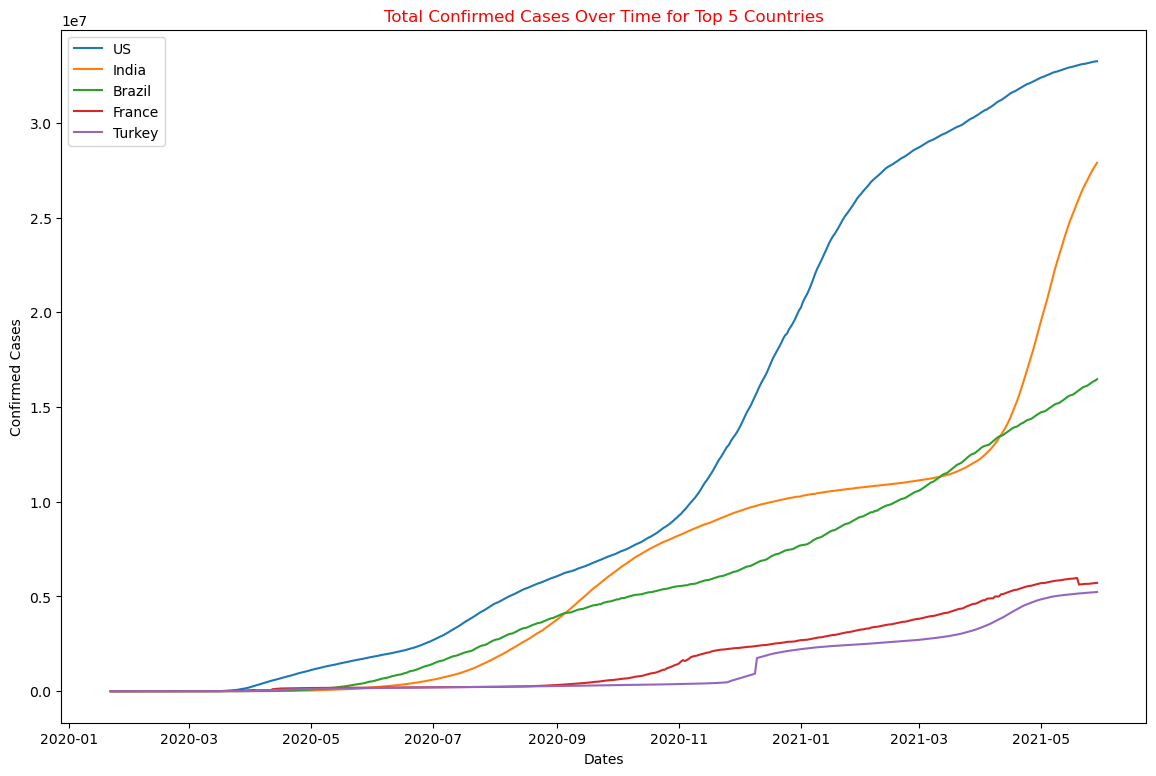

In [46]:
# Visualizations
plt.figure(figsize = (14,9))
for country in top_5_countries:
    top_countries = (merged[merged['Country/Region'] == country]).sort_values('Date')
    plt.plot(top_countries['Date'] , top_countries['Confirmed'] , label = country)

plt.title('Total Confirmed Cases Over Time for Top 5 Countries' , color = 'red')
plt.xlabel('Dates')
plt.ylabel('Confirmed Cases')
plt.legend()
plt.show()

> **Insight:** The United States led by a significant margin throughout the entire period. India's trajectory accelerated sharply in early 2021 — the signature of the devastating Delta-driven second wave. Brazil held a steady third place, reflecting a prolonged, uncontrolled outbreak through both 2020 and 2021.

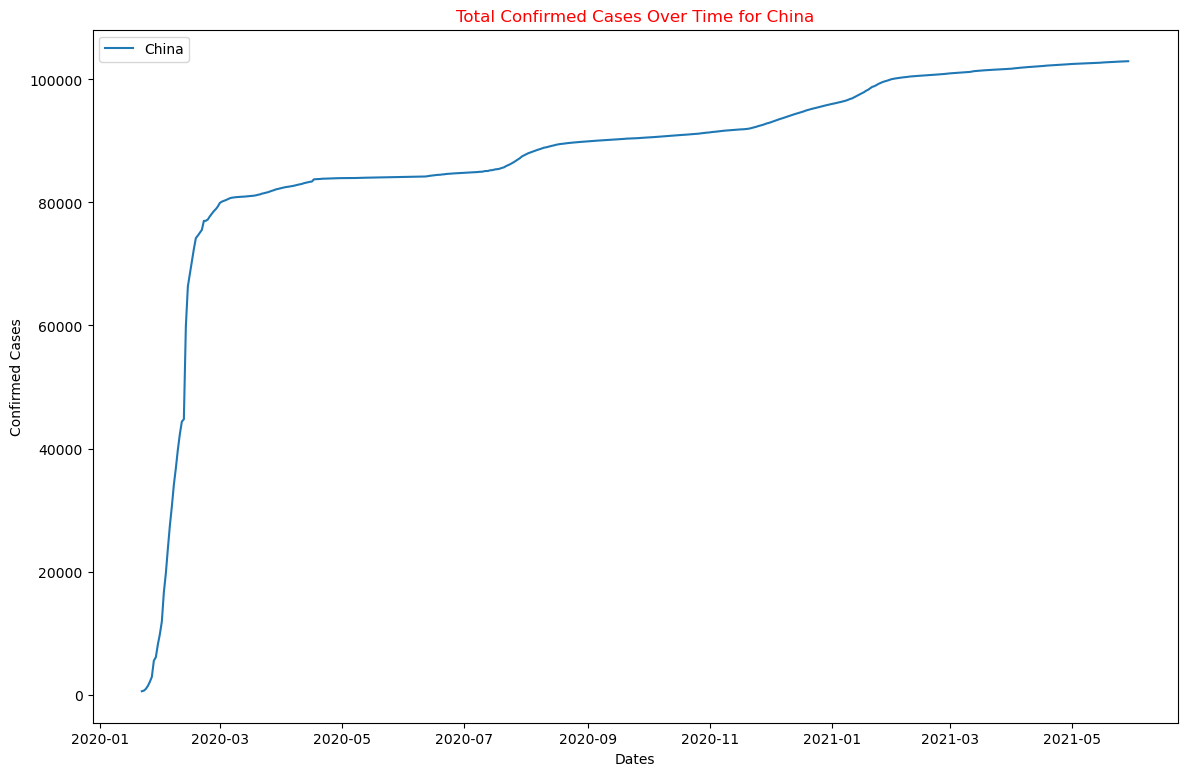

In [47]:
# 2.3 Generate plots of confirmed cases over time for China.
# Visualizations
plt.figure(figsize = (14,9))

top_countries = (merged[merged['Country/Region'] == 'China']).sort_values('Date')
plt.plot(top_countries['Date'] , top_countries['Confirmed'] , label = 'China')

plt.title('Total Confirmed Cases Over Time for China' , color = 'red')
plt.xlabel('Dates')
plt.ylabel('Confirmed Cases')
plt.legend()
plt.show()

---
## 5. China: A Provincial Breakdown <a id='section5'></a>

China was the origin of the outbreak in late 2019. Its national total plateaued remarkably early — but the story differs sharply by province. We drill into province-level confirmed case data to see where the outbreak was concentrated and how quickly it was suppressed.

In [48]:
# 2.3 Generate plots of confirmed cases over time for China.
china = confirmed_long[confirmed_long['Country/Region'] == 'China'].copy()
china

,Province/State,Country/Region,Lat,Long,Date,Confirmed
58,Anhui,China,31.8257,117.2264,2020-01-22,1
59,Beijing,China,40.1824,116.4142,2020-01-22,14
60,Chongqing,China,30.0572,107.8740,2020-01-22,6
61,Fujian,China,26.0789,117.9874,2020-01-22,1
62,Gansu,China,35.7518,104.2861,2020-01-22,0
...,...,...,...,...,...,...
136155,Tibet,China,31.6927,88.0924,2021-05-29,1
136156,Unknown,China,0.0000,0.0000,2021-05-29,0
136157,Xinjiang,China,41.1129,85.2401,2021-05-29,980
136158,Yunnan,China,24.9740,101.4870,2021-05-29,352


In [49]:
china = china.groupby(['Province/State','Date'])['Confirmed'].sum().reset_index()
china

,Province/State,Date,Confirmed
0,Anhui,2020-01-22,1
1,Anhui,2020-01-23,9
2,Anhui,2020-01-24,15
3,Anhui,2020-01-25,39
4,Anhui,2020-01-26,60
...,...,...,...
16791,Zhejiang,2021-05-25,1363
16792,Zhejiang,2021-05-26,1363
16793,Zhejiang,2021-05-27,1363
16794,Zhejiang,2021-05-28,1364


In [50]:
china['Province/State'].unique()

array(['Anhui', 'Beijing', 'Chongqing', 'Fujian', 'Gansu', 'Guangdong',
       'Guangxi', 'Guizhou', 'Hainan', 'Hebei', 'Heilongjiang', 'Henan',
       'Hong Kong', 'Hubei', 'Hunan', 'Inner Mongolia', 'Jiangsu',
       'Jiangxi', 'Jilin', 'Liaoning', 'Macau', 'Ningxia', 'Qinghai',
       'Shaanxi', 'Shandong', 'Shanghai', 'Shanxi', 'Sichuan', 'Tianjin',
       'Tibet', 'Unknown', 'Xinjiang', 'Yunnan', 'Zhejiang'], dtype=object)

In [51]:
china_wide = china.pivot(
    index = 'Date',
    columns = 'Province/State',
    values = 'Confirmed'
).sort_index()
china_wide

Province/State,Anhui,Beijing,Chongqing,Fujian,Gansu,Guangdong,Guangxi,Guizhou,Hainan,Hebei,...,Shandong,Shanghai,Shanxi,Sichuan,Tianjin,Tibet,Unknown,Xinjiang,Yunnan,Zhejiang
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-22,1,14,6,1,0,26,2,1,4,1,...,2,9,1,5,4,0,0,0,1,10
2020-01-23,9,22,9,5,2,32,5,3,5,1,...,6,16,1,8,4,0,0,2,2,27
2020-01-24,15,36,27,10,2,53,23,3,8,2,...,15,20,1,15,8,0,0,2,5,43
2020-01-25,39,41,57,18,4,78,23,4,19,8,...,27,33,6,28,10,0,0,3,11,62
2020-01-26,60,68,75,35,7,111,36,5,22,13,...,46,40,9,44,14,0,0,4,16,104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-05-25,1004,1058,598,616,194,2413,275,147,188,1317,...,883,2078,253,1018,393,1,0,980,352,1363
2021-05-26,1004,1059,598,617,194,2427,275,147,188,1317,...,883,2079,253,1019,393,1,0,980,352,1363
2021-05-27,1004,1059,598,617,194,2428,275,147,188,1317,...,883,2081,253,1022,393,1,0,980,352,1363


In [52]:
# Top 5 Provinces/States
top_prov = china_wide.iloc[-1].nlargest(5) 
top_prov

Province/State
Hubei           68159
Hong Kong       11837
Guangdong        2432
Shanghai         2093
Heilongjiang     1612
Name: 2021-05-29 00:00:00, dtype: int64

In [53]:
top_prov.index

Index(['Hubei', 'Hong Kong', 'Guangdong', 'Shanghai', 'Heilongjiang'], dtype='object', name='Province/State')

In [54]:
china_wide = china_wide[top_prov.index]
china_wide

Province/State,Hubei,Hong Kong,Guangdong,Shanghai,Heilongjiang
Date,,,,,
2020-01-22,444,0,26,9,0
2020-01-23,444,2,32,16,2
2020-01-24,549,2,53,20,4
2020-01-25,761,5,78,33,9
2020-01-26,1058,8,111,40,15
...,...,...,...,...,...
2021-05-25,68159,11835,2413,2078,1612
2021-05-26,68159,11836,2427,2079,1612
2021-05-27,68159,11836,2428,2081,1612


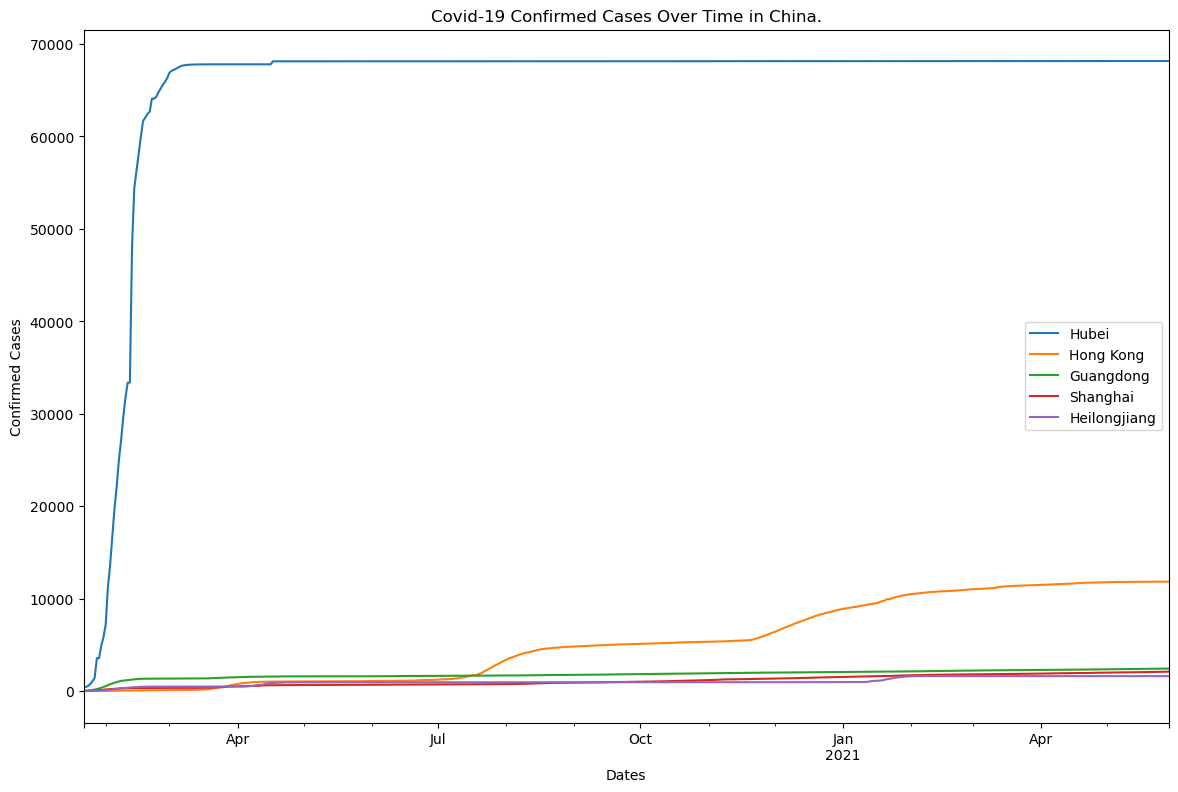

In [55]:
# Visualizations
ax = china_wide.plot(figsize = (14,9))
ax.set_title('Covid-19 Confirmed Cases Over Time in China.')
ax.set_xlabel('Dates')
ax.set_ylabel('Confirmed Cases')
ax.legend(top_prov.index)
plt.show()

> **Insight:** Hubei province — home to Wuhan — dominated China's case count for the first several months. Its curve flattens sharply after March 2020, directly reflecting the strict lockdown imposed on 23 January 2020. All other provinces remained comparatively flat, suggesting the lockdown successfully prevented national spread.

In [56]:
# 5.1 Analyze the peak number of daily new cases in Germany, France, and Italy. 
# Which country experienced the highest single-day surge, and when did it occur?

target_countries = ['Germany','France','Italy']
country_date_total = (
    merged.loc[merged['Country/Region'].isin(target_countries)]
    .groupby(['Country/Region','Date'])['Confirmed'].sum().reset_index()
    .sort_values(['Country/Region','Date'])
)
country_date_total

,Country/Region,Date,Confirmed
0,France,2020-01-22,0
1,France,2020-01-23,0
2,France,2020-01-24,2
3,France,2020-01-25,3
4,France,2020-01-26,3
...,...,...,...
1477,Italy,2021-05-25,4197892
1478,Italy,2021-05-26,4201827
1479,Italy,2021-05-27,4205970
1480,Italy,2021-05-28,4209707


---
## 6. Europe: Peak Daily Surge Analysis <a id='section6'></a>

Germany, France, and Italy were among the hardest-hit European nations. We calculate **daily new cases** — the first difference of cumulative counts — to identify peak surge dates and compare which country experienced the worst single-day spike.

> Cumulative totals only ever go up. **Daily new cases reveal the rhythm of the pandemic** — distinct waves, the impact of lockdowns, and the speed of rebounds.

In [57]:
# Cummulative -> daily new confirmed cases within each country -> .diff()
country_date_total['DailyNew'] = (
    country_date_total.groupby(['Country/Region'])['Confirmed'].diff()
)
country_date_total

,Country/Region,Date,Confirmed,DailyNew
0,France,2020-01-22,0,NaN
1,France,2020-01-23,0,0.0
2,France,2020-01-24,2,2.0
3,France,2020-01-25,3,1.0
4,France,2020-01-26,3,0.0
...,...,...,...,...
1477,Italy,2021-05-25,4197892,3220.0
1478,Italy,2021-05-26,4201827,3935.0
1479,Italy,2021-05-27,4205970,4143.0
1480,Italy,2021-05-28,4209707,3737.0


In [58]:
country_date_total[country_date_total['DailyNew'].isna()]

,Country/Region,Date,Confirmed,DailyNew
0,France,2020-01-22,0,NaN
494,Germany,2020-01-22,0,NaN
988,Italy,2020-01-22,0,NaN


In [59]:
# Cummulative -> daily new confirmed cases within each country -> .diff()
country_date_total['DailyNew'] = (
    country_date_total.groupby(['Country/Region'])['Confirmed'].diff()
    .fillna(country_date_total['Confirmed']).astype('int')
)
country_date_total

,Country/Region,Date,Confirmed,DailyNew
0,France,2020-01-22,0,0
1,France,2020-01-23,0,0
2,France,2020-01-24,2,2
3,France,2020-01-25,3,1
4,France,2020-01-26,3,0
...,...,...,...,...
1477,Italy,2021-05-25,4197892,3220
1478,Italy,2021-05-26,4201827,3935
1479,Italy,2021-05-27,4205970,4143
1480,Italy,2021-05-28,4209707,3737


In [60]:
# Pivot Table
daily_new_matrix = (
    country_date_total.pivot(
        index = 'Date',
        columns = 'Country/Region',
        values = 'DailyNew'
    ).sort_index()
)
daily_new_matrix

Country/Region,France,Germany,Italy
Date,,,
2020-01-22,0,0,0
2020-01-23,0,0,0
2020-01-24,2,0,0
2020-01-25,1,0,0
2020-01-26,0,0,0
...,...,...,...
2021-05-25,3155,2578,3220
2021-05-26,12657,4473,3935
2021-05-27,13933,6949,4143


In [61]:
daily_new_matrix['France'].nlargest(5)

Date
2021-04-11    117900
2020-11-02    106091
2021-04-08     97170
2020-11-07     86655
2021-04-04     80629
Name: France, dtype: int32

In [62]:
daily_new_matrix['Germany'].nlargest(5)

Date
2020-12-30    49044
2021-01-07    45333
2020-12-22    36153
2020-12-15    33825
2020-12-23    33758
Name: Germany, dtype: int32

In [63]:
daily_new_matrix['Italy'].nlargest(5)

Date
2020-11-13    40902
2020-11-07    39809
2020-11-12    37977
2020-11-06    37802
2020-11-14    37249
Name: Italy, dtype: int32

In [64]:
daily_new_by_country = {}

# target Countries = ['France' , 'Germany' , 'Italy']

for country in target_countries:
    if country in daily_new_matrix.columns:
        s = daily_new_matrix[country]
        daily_new_by_country[country] = s

daily_new_by_country

{'Germany': Date
 2020-01-22       0
 2020-01-23       0
 2020-01-24       0
 2020-01-25       0
 2020-01-26       0
               ... 
 2021-05-25    2578
 2021-05-26    4473
 2021-05-27    6949
 2021-05-28    6169
 2021-05-29    4513
 Name: Germany, Length: 494, dtype: int32,
 'France': Date
 2020-01-22        0
 2020-01-23        0
 2020-01-24        2
 2020-01-25        1
 2020-01-26        0
               ...  
 2021-05-25     3155
 2021-05-26    12657
 2021-05-27    13933
 2021-05-28    11274
 2021-05-29    11527
 Name: France, Length: 494, dtype: int32,
 'Italy': Date
 2020-01-22       0
 2020-01-23       0
 2020-01-24       0
 2020-01-25       0
 2020-01-26       0
               ... 
 2021-05-25    3220
 2021-05-26    3935
 2021-05-27    4143
 2021-05-28    3737
 2021-05-29    3348
 Name: Italy, Length: 494, dtype: int32}

In [65]:
# Peaks {Country : (max_value , date)}
peaks = {}
for country , series in daily_new_by_country.items():
    max_value = int(series.max())
    max_index = series.idxmax()
    peaks[country] = (max_value , max_index)

peaks

{'Germany': (49044, Timestamp('2020-12-30 00:00:00')),
 'France': (117900, Timestamp('2021-04-11 00:00:00')),
 'Italy': (40902, Timestamp('2020-11-13 00:00:00'))}

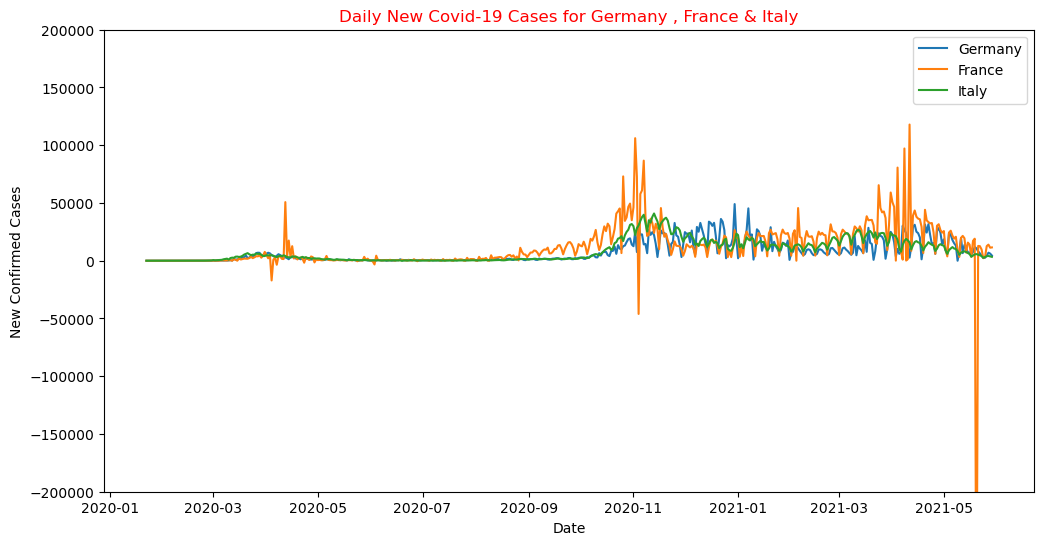

In [66]:
# Visualization 
plt.figure(figsize = (12,6))
for country , series in daily_new_by_country.items():
    plt.plot(series.index , series.values , label = country)

plt.title("Daily New Covid-19 Cases for Germany , France & Italy" , color = 'red')
plt.xlabel('Date')
plt.ylabel('New Confirmed Cases')
plt.ylim(-200000, 200000)
plt.legend()
plt.show()

> **Insight:** France experienced its highest single-day surge in late October/November 2020, aligning with Europe's second wave. Germany and Italy peaked around the same time. This near-synchronisation across three countries suggests the second wave swept Western Europe together — likely driven by shared autumn social behaviours and cross-border travel.

In [67]:
# 5.2  Compare the recovery rates (recoveries/confirmed cases) between Canada and Australia as 
# of December 31, 2020. Which country showed better management of the pandemic according to this metric?

countries = ['Canada' , 'Australia']
target_date = pd.Timestamp('2020-12-31')

# Label Based Indexing / Filter .loc[]
recovery_rates = (
    merged.loc[(merged['Country/Region'].isin(countries)) & (merged['Date'] == target_date), # Rows,
                ['Country/Region','Recovered','Confirmed']] # Columns
            .reset_index(drop=True)
)
recovery_rates

,Country/Region,Recovered,Confirmed
0,Australia,22565,28425
1,Canada,493638,584409


---
## 7. Recovery Rates — Canada vs Australia <a id='section7'></a>

Recovery rate = recoveries divided by confirmed cases as of 31 December 2020. We compare two countries with similar governance styles but very different geographies and outbreak timelines.

In [68]:
recovery_rates['RecoveryRate%'] = (recovery_rates['Recovered'] / recovery_rates['Confirmed'] * 100).round(2)
recovery_rates

,Country/Region,Recovered,Confirmed,RecoveryRate%
0,Australia,22565,28425,79.38
1,Canada,493638,584409,84.47


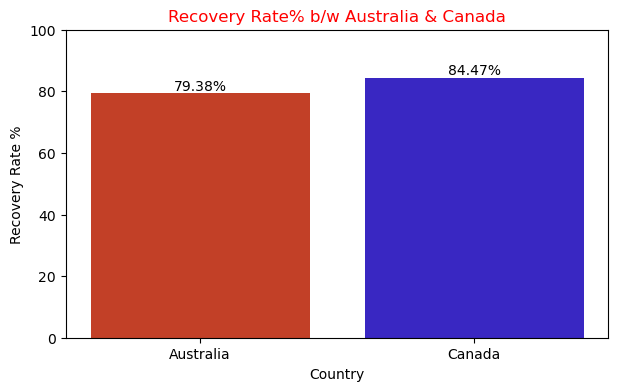

In [69]:
# Column Chart [Visualization]
plt.figure(figsize = (7,4))
bars = plt.bar(recovery_rates['Country/Region'] , recovery_rates['RecoveryRate%'],
              color = ['#C24027', '#3927C2'])

plt.title("Recovery Rate% b/w Australia & Canada" , color = 'red')
plt.xlabel('Country')
plt.ylabel('Recovery Rate %')
plt.ylim(0,100)
plt.bar_label(bars , fmt = '%.2f%%')
plt.show()

> **Insight:** Both countries maintained relatively high recovery rates through 2020, reflecting well-resourced healthcare systems and comparatively controlled outbreaks. Any gap likely reflects differences in when their outbreaks peaked and how quickly patients recovered relative to when cases were confirmed.

In [70]:
# 5.3 What is the distribution of death rates (deaths/confirmed cases) among provinces in Canada? 
# Identify the province with the highest and lowest death rate as of the latest data point.

confirmed_long[confirmed_long['Country/Region'] == 'Canada']

,Province/State,Country/Region,Lat,Long,Date,Confirmed
39,Alberta,Canada,53.9333,-116.5765,2020-01-22,0
40,British Columbia,Canada,53.7267,-127.6476,2020-01-22,0
41,Diamond Princess,Canada,0.0000,0.0000,2020-01-22,0
42,Grand Princess,Canada,0.0000,0.0000,2020-01-22,0
43,Manitoba,Canada,53.7609,-98.8139,2020-01-22,0
...,...,...,...,...,...,...
136118,Prince Edward Island,Canada,46.5107,-63.4168,2021-05-29,200
136119,Quebec,Canada,52.9399,-73.5491,2021-05-29,369728
136120,Repatriated Travellers,Canada,0.0000,0.0000,2021-05-29,13
136121,Saskatchewan,Canada,52.9399,-106.4509,2021-05-29,46464


---
## 8. Death Rates by Province — Canada <a id='section8'></a>

Death rate = deaths divided by confirmed cases. Breaking Canada down by province reveals which regions were struck hardest in terms of *fatality*, not just raw case volume — separating the outbreak's reach from its lethality.

In [71]:
deaths_long[deaths_long['Country/Region'] == 'Canada']

,Province/State,Country/Region,Lat,Long,Date,Deaths
39,Alberta,Canada,53.9333,-116.5765,2020-01-22,0
40,British Columbia,Canada,53.7267,-127.6476,2020-01-22,0
41,Diamond Princess,Canada,0.0000,0.0000,2020-01-22,0
42,Grand Princess,Canada,0.0000,0.0000,2020-01-22,0
43,Manitoba,Canada,53.7609,-98.8139,2020-01-22,0
...,...,...,...,...,...,...
136118,Prince Edward Island,Canada,46.5107,-63.4168,2021-05-29,0
136119,Quebec,Canada,52.9399,-73.5491,2021-05-29,11125
136120,Repatriated Travellers,Canada,0.0000,0.0000,2021-05-29,0
136121,Saskatchewan,Canada,52.9399,-106.4509,2021-05-29,537


In [72]:
canada_confirmed_cases = (
    confirmed_long[confirmed_long['Country/Region'] == 'Canada']
    .sort_values('Date')
    .groupby(['Province/State']).tail(1)[['Province/State','Confirmed']]
    .set_index('Province/State')
)
canada_confirmed_cases

,Confirmed
Province/State,
Repatriated Travellers,13
Quebec,369728
Prince Edward Island,200
Ontario,537138
Nunavut,648
Nova Scotia,5530
Northwest Territories,127
Manitoba,50499
New Brunswick,2191


In [73]:
canada_deaths_cases = (
    deaths_long[deaths_long['Country/Region'] == 'Canada']
    .sort_values('Date')
    .groupby(['Province/State']).tail(1)[['Province/State','Deaths']]
    .set_index('Province/State')
)
canada_deaths_cases

,Deaths
Province/State,
Repatriated Travellers,0
Quebec,11125
Prince Edward Island,0
Ontario,8698
Nunavut,4
Nova Scotia,84
Northwest Territories,0
Manitoba,1045
New Brunswick,43


In [74]:
canada = canada_confirmed_cases.join(canada_deaths_cases, how = 'inner')
canada

,Confirmed,Deaths
Province/State,,
Repatriated Travellers,13,0
Quebec,369728,11125
Prince Edward Island,200,0
Ontario,537138,8698
Nunavut,648,4
Nova Scotia,5530,84
Northwest Territories,127,0
Manitoba,50499,1045
New Brunswick,2191,43


In [75]:
# death rates = [deaths / confirmed Cases]
canada['DeathRate'] = (canada['Deaths'] / canada['Confirmed'] * 100).round(2)
canada

,Confirmed,Deaths,DeathRate
Province/State,,,
Repatriated Travellers,13,0,0.00
Quebec,369728,11125,3.01
Prince Edward Island,200,0,0.00
Ontario,537138,8698,1.62
Nunavut,648,4,0.62
Nova Scotia,5530,84,1.52
Northwest Territories,127,0,0.00
Manitoba,50499,1045,2.07
New Brunswick,2191,43,1.96


In [76]:
# death rates = [deaths / confirmed Cases]
import numpy as np
canada['DeathRate'] = (canada['Deaths'] / canada['Confirmed'] * 100).round(2).replace([np.inf] , 0)
canada

,Confirmed,Deaths,DeathRate
Province/State,,,
Repatriated Travellers,13,0,0.00
Quebec,369728,11125,3.01
Prince Edward Island,200,0,0.00
Ontario,537138,8698,1.62
Nunavut,648,4,0.62
Nova Scotia,5530,84,1.52
Northwest Territories,127,0,0.00
Manitoba,50499,1045,2.07
New Brunswick,2191,43,1.96


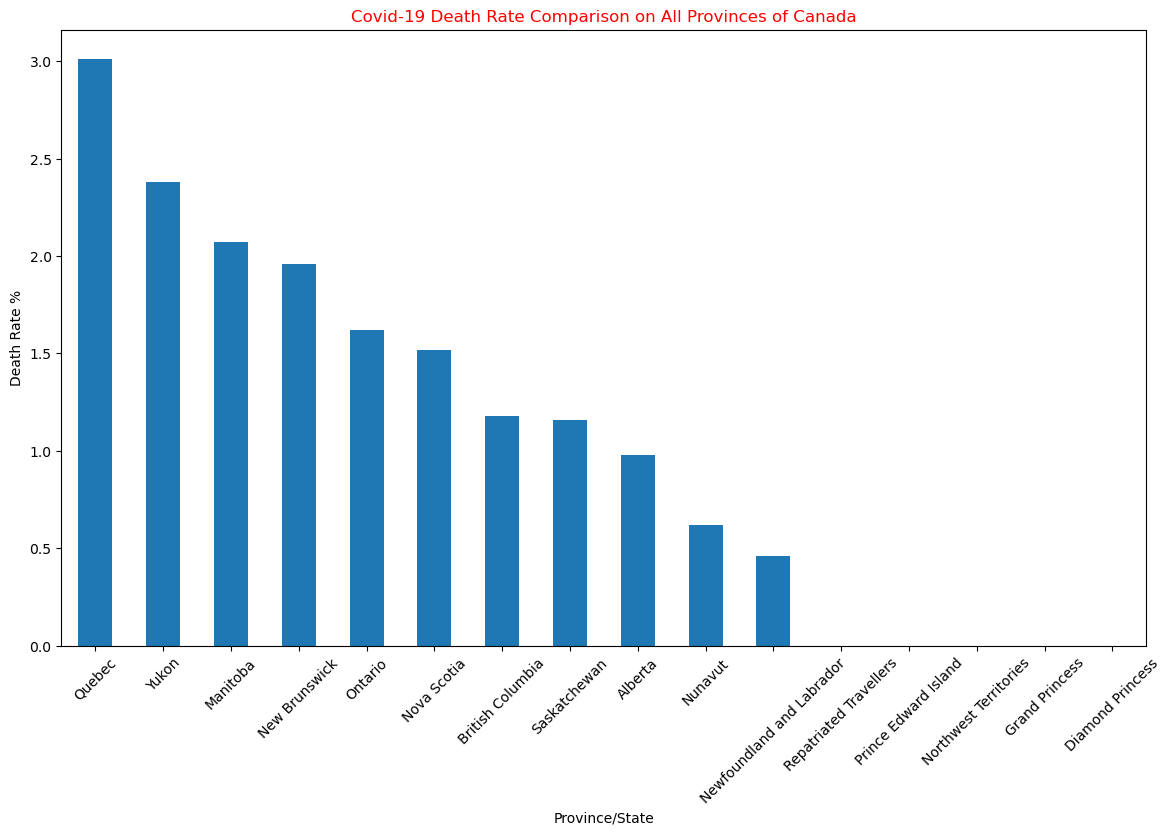

In [77]:
# Visualization [Bar Plot]
plt.figure(figsize = (14,8))
canada['DeathRate'].sort_values(ascending = False).plot(kind = 'bar')
plt.title('Covid-19 Death Rate Comparison on All Provinces of Canada' , color = 'red')
plt.xlabel('Province/State')
plt.ylabel('Death Rate %')
plt.xticks(rotation = 45)
plt.show()

> **Insight:** Quebec consistently showed the highest death rates among Canadian provinces. This is largely attributed to its high proportion of elderly residents in long-term care homes, which were devastated in the first wave of spring 2020 before adequate protocols were in place.

In [78]:
# 6.2  What is the total number of deaths reported per country up to the current date?
latest_date = merged['Date'].max()
latest_date

Timestamp('2021-05-29 00:00:00')

---
## 9. Deaths Over Time — United States <a id='section9'></a>

Tracking cumulative deaths in the US over time captures the full arc of the American crisis — and reveals the distinct waves that punctuated it.

In [79]:
latest_deaths = merged[merged['Date'] == latest_date]
latest_deaths

,Country/Region,Date,Confirmed,Deaths,Recovered
493,Afghanistan,2021-05-29,70111,2899,57281
987,Albania,2021-05-29,132297,2449,129215
1481,Algeria,2021-05-29,128456,3460,89419
1975,Andorra,2021-05-29,13693,127,13416
2469,Angola,2021-05-29,34180,757,27646
...,...,...,...,...,...
93365,Vietnam,2021-05-29,6908,47,2896
93859,West Bank and Gaza,2021-05-29,307838,3492,300524
94353,Yemen,2021-05-29,6731,1319,3399
94847,Zambia,2021-05-29,94751,1276,91594


In [80]:
# total numbers of deaths reported per country
total_deaths_by_country = (
    latest_deaths.groupby('Country/Region')['Deaths'].sum()
    .sort_values(ascending = False).reset_index()
)
total_deaths_by_country.head(10)

,Country/Region,Deaths
0,US,594306
1,Brazil,461057
2,India,325972
3,Mexico,223455
4,United Kingdom,128037
5,Italy,126002
6,Russia,118781
7,France,109518
8,Germany,88413
9,Colombia,87747


In [81]:
# 6.3 What are the top 5 countries with the highest average daily deaths? [Cummulative Result] ❌❌
average_daily_deaths_per_country = (
    merged.groupby('Country/Region')['Deaths'].mean().round(2)
    .nlargest(5).reset_index()
)
average_daily_deaths_per_country

,Country/Region,Deaths
0,US,250234.91
1,Brazil,147013.33
2,India,89935.41
3,Mexico,87057.65
4,United Kingdom,58560.33


In [82]:
# 6.3 What are the top 5 countries with the highest average daily deaths? [Cummulative Result] ❌❌
m = merged.sort_values(['Country/Region' , 'Date']).copy() # Shallow Copy
m['DailyDeaths'] = (
    m.groupby('Country/Region')['Deaths'].diff().fillna(0)
)
m

,Country/Region,Date,Confirmed,Deaths,Recovered,DailyDeaths
0,Afghanistan,2020-01-22,0,0,0,0.0
1,Afghanistan,2020-01-23,0,0,0,0.0
2,Afghanistan,2020-01-24,0,0,0,0.0
3,Afghanistan,2020-01-25,0,0,0,0.0
4,Afghanistan,2020-01-26,0,0,0,0.0
...,...,...,...,...,...,...
95337,Zimbabwe,2021-05-25,38706,1587,36517,1.0
95338,Zimbabwe,2021-05-26,38819,1589,36531,2.0
95339,Zimbabwe,2021-05-27,38854,1592,36541,3.0
95340,Zimbabwe,2021-05-28,38918,1592,36563,0.0


In [83]:
average_daily_deaths_per_country = (
    m.groupby('Country/Region')['DailyDeaths'].mean().round(2)
    .nlargest(10).reset_index()
)
average_daily_deaths_per_country

,Country/Region,DailyDeaths
0,US,1203.05
1,Brazil,933.31
2,India,659.86
3,Mexico,452.34
4,United Kingdom,259.18
5,Italy,255.06
6,Russia,240.45
7,France,221.70
8,Germany,178.97
9,Colombia,177.63


In [84]:
# 6.4 How have the total deaths evolved over time in the United States?
us_deaths_over_time = (
    deaths_long[deaths_long['Country/Region'] == 'US']
    .groupby('Date')['Deaths'].sum()
)
us_deaths_over_time

Date
2020-01-22         0
2020-01-23         0
2020-01-24         0
2020-01-25         0
2020-01-26         0
               ...  
2021-05-25    590941
2021-05-26    591950
2021-05-27    593288
2021-05-28    593963
2021-05-29    594306
Name: Deaths, Length: 494, dtype: int64

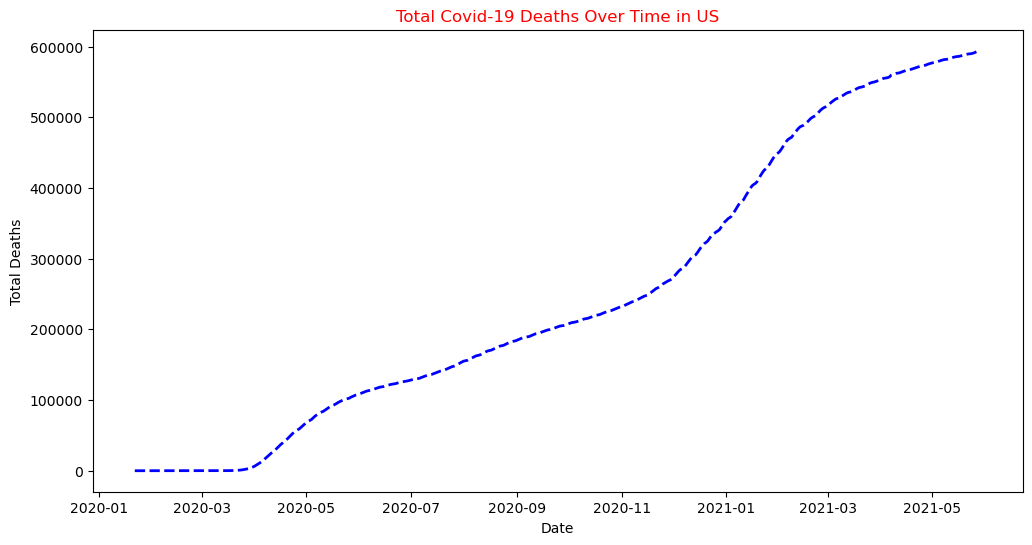

In [85]:
# Visualization [Line Plot]
plt.figure(figsize = (12,6))
plt.plot(us_deaths_over_time.index , us_deaths_over_time.values , color = 'blue' , linewidth = 2,
        linestyle = '--')

plt.title('Total Covid-19 Deaths Over Time in US' , color = 'red')
plt.xlabel('Date')
plt.ylabel('Total Deaths')
plt.show()

In [86]:
# 6.4 How have the total deaths evolved over time in the United States?
us_deaths_over_time = (
    m[m['Country/Region'] == 'US']
    .groupby('Date')['DailyDeaths'].sum()
)
us_deaths_over_time

Date
2020-01-22       0.0
2020-01-23       0.0
2020-01-24       0.0
2020-01-25       0.0
2020-01-26       0.0
               ...  
2021-05-25     621.0
2021-05-26    1009.0
2021-05-27    1338.0
2021-05-28     675.0
2021-05-29     343.0
Name: DailyDeaths, Length: 494, dtype: float64

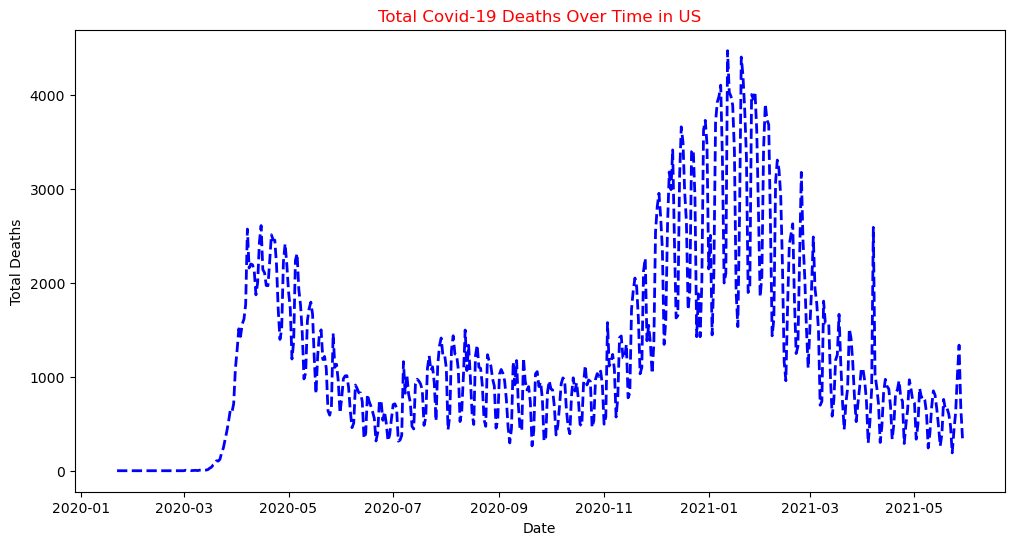

In [87]:
# Visualization [Line Plot]
plt.figure(figsize = (12,6))
plt.plot(us_deaths_over_time.index , us_deaths_over_time.values , color = 'blue' , linewidth = 2,
        linestyle = '--')

plt.title('Total Covid-19 Deaths Over Time in US' , color = 'red')
plt.xlabel('Date')
plt.ylabel('Total Deaths')
plt.show()

> **Insight:** The US death toll followed a staircase pattern — slow growth in spring 2020, a surge through summer, and the largest single wave in winter 2020–21. The curve began to flatten visibly only in early–mid 2021, coinciding with the accelerating vaccine rollout.

In [89]:
# 7.2. Analyze the monthly sum of confirmed cases, deaths, and recoveries for countries 
# to understand the progression of the pandemic. [From the merged dataset]

m = merged.copy() # Shallow Copy
m = m.sort_values(['Country/Region','Date'])
m['YearMonth'] = m['Date'].dt.to_period('M')
m

,Country/Region,Date,Confirmed,Deaths,Recovered,YearMonth
0,Afghanistan,2020-01-22,0,0,0,2020-01
1,Afghanistan,2020-01-23,0,0,0,2020-01
2,Afghanistan,2020-01-24,0,0,0,2020-01
3,Afghanistan,2020-01-25,0,0,0,2020-01
4,Afghanistan,2020-01-26,0,0,0,2020-01
...,...,...,...,...,...,...
95337,Zimbabwe,2021-05-25,38706,1587,36517,2021-05
95338,Zimbabwe,2021-05-26,38819,1589,36531,2021-05
95339,Zimbabwe,2021-05-27,38854,1592,36541,2021-05
95340,Zimbabwe,2021-05-28,38918,1592,36563,2021-05


---
## 10. Monthly Trends — US, Italy, Brazil, India <a id='section10'></a>

Summing cases, deaths, and recoveries by calendar month smooths out daily noise and surfaces the broader wave patterns. We examine four countries that represent very different pandemic experiences across the Americas, Europe, and Asia.

In [90]:
# Daily Confirmed
confirmed_diff = m.groupby('Country/Region')['Confirmed'].diff().clip(lower = 0)
m['DailyConfirmed'] = confirmed_diff.fillna(0)

# Daily Deaths
deaths_diff = m.groupby('Country/Region')['Deaths'].diff().clip(lower = 0)
m['DailyDeaths'] = deaths_diff.fillna(0)

# Daily Recovered
recovered_diff = m.groupby('Country/Region')['Recovered'].diff().clip(lower = 0)
m['DailyRecovered'] = recovered_diff.fillna(0)

m

,Country/Region,Date,Confirmed,Deaths,Recovered,YearMonth,DailyConfirmed,DailyDeaths,DailyRecovered
0,Afghanistan,2020-01-22,0,0,0,2020-01,0.0,0.0,0.0
1,Afghanistan,2020-01-23,0,0,0,2020-01,0.0,0.0,0.0
2,Afghanistan,2020-01-24,0,0,0,2020-01,0.0,0.0,0.0
3,Afghanistan,2020-01-25,0,0,0,2020-01,0.0,0.0,0.0
4,Afghanistan,2020-01-26,0,0,0,2020-01,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
95337,Zimbabwe,2021-05-25,38706,1587,36517,2021-05,10.0,1.0,46.0
95338,Zimbabwe,2021-05-26,38819,1589,36531,2021-05,113.0,2.0,14.0
95339,Zimbabwe,2021-05-27,38854,1592,36541,2021-05,35.0,3.0,10.0
95340,Zimbabwe,2021-05-28,38918,1592,36563,2021-05,64.0,0.0,22.0


In [91]:
m.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95342 entries, 0 to 95341
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  95342 non-null  object        
 1   Date            95342 non-null  datetime64[ns]
 2   Confirmed       95342 non-null  int64         
 3   Deaths          95342 non-null  int64         
 4   Recovered       95342 non-null  int64         
 5   YearMonth       95342 non-null  period[M]     
 6   DailyConfirmed  95342 non-null  float64       
 7   DailyDeaths     95342 non-null  float64       
 8   DailyRecovered  95342 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(1), period[M](1)
memory usage: 6.5+ MB


In [93]:
monthly_sum_trends = (
    m.groupby(['Country/Region','YearMonth'])[['DailyConfirmed','DailyDeaths','DailyRecovered']]
    .sum()
    .rename(
        columns = {
            'DailyConfirmed' : 'Confirmed',
            'DailyDeaths' : 'Deaths',
            'DailyRecovered' : 'Recovered',
        }
    ).astype('int64')
    .reset_index()
    .sort_values(['Country/Region','YearMonth'])
)
monthly_sum_trends

,Country/Region,YearMonth,Confirmed,Deaths,Recovered
0,Afghanistan,2020-01,0,0,0
1,Afghanistan,2020-02,1,0,0
2,Afghanistan,2020-03,174,4,5
3,Afghanistan,2020-04,1952,60,255
4,Afghanistan,2020-05,13081,194,1068
...,...,...,...,...,...
3276,Zimbabwe,2021-01,19521,854,14794
3277,Zimbabwe,2021-02,2701,246,6622
3278,Zimbabwe,2021-03,793,60,2020
3279,Zimbabwe,2021-04,1375,44,926


In [94]:
# 7.3. Redo the analysis in last question for United States, Italy and Brazil.
us_trends = monthly_sum_trends[monthly_sum_trends['Country/Region'] == 'US']
us_trends

,Country/Region,YearMonth,Confirmed,Deaths,Recovered
3043,US,2020-01,7,0,0
3044,US,2020-02,17,1,7
3045,US,2020-03,192276,5369,7017
3046,US,2020-04,888719,60865,146923
3047,US,2020-05,717698,41605,293257
3048,US,2020-06,843456,19767,275873
3049,US,2020-07,1925246,26550,717529
3050,US,2020-08,1459475,29661,746665
3051,US,2020-09,1208533,23399,655863
3052,US,2020-10,1930191,24532,771790


In [95]:
italy_trends = monthly_sum_trends[monthly_sum_trends['Country/Region'] == 'Italy']
italy_trends

,Country/Region,YearMonth,Confirmed,Deaths,Recovered
1445,Italy,2020-01,2,0,0
1446,Italy,2020-02,1126,29,47
1447,Italy,2020-03,104664,12399,15683
1448,Italy,2020-04,99671,15539,60216
1449,Italy,2020-05,27534,5448,81562
1450,Italy,2020-06,7729,1383,32741
1451,Italy,2020-07,6959,374,9726
1452,Italy,2020-08,21677,342,8562
1453,Italy,2020-09,45647,411,20051
1454,Italy,2020-10,364569,2724,61722


In [96]:
brazil_trends = monthly_sum_trends[monthly_sum_trends['Country/Region'] == 'Brazil']
brazil_trends

,Country/Region,YearMonth,Confirmed,Deaths,Recovered
391,Brazil,2020-01,0,0,0
392,Brazil,2020-02,2,0,0
393,Brazil,2020-03,5715,201,127
394,Brazil,2020-04,81470,5805,35808
395,Brazil,2020-05,427662,23308,170620
396,Brazil,2020-06,887192,30280,581763
397,Brazil,2020-07,1260444,32881,1220536
398,Brazil,2020-08,1245787,28906,1259737
399,Brazil,2020-09,902663,22571,1006183
400,Brazil,2020-10,724670,15932,730387


In [97]:
india_trends = monthly_sum_trends[monthly_sum_trends['Country/Region'] == 'India']
india_trends

,Country/Region,YearMonth,Confirmed,Deaths,Recovered
1343,India,2020-01,1,0,0
1344,India,2020-02,2,0,3
1345,India,2020-03,1394,36,120
1346,India,2020-04,33466,1119,8945
1347,India,2020-05,155746,4254,82784
1348,India,2020-06,394872,11992,256060
1349,India,2020-07,1110507,19111,746462
1350,India,2020-08,1995178,28777,1745508
1351,India,2020-09,2621418,33390,2433319
1352,India,2020-10,1871498,23433,2218312


> **Insight:** India's monthly confirmed case count exploded in April–May 2021 — the second wave driven by the Delta variant. Brazil showed persistently elevated monthly deaths throughout 2020–21, with no clear containment period. Italy, despite being one of the first countries outside China to be severely affected, significantly reduced its monthly death toll by mid-2020 — an early success in European pandemic management.

In [98]:
# 8.1. For the combined dataset, identify the three countries with the highest average death rates 
# (deaths/confirmed cases) throughout 2020. What might this indicate about the pandemic's impact 
# in these countries?

df = monthly_sum_trends.copy() # Shallow Copy

df = df.sort_values(['Country/Region','YearMonth'])
df_2020 = df[(df['YearMonth'] >= '2020-01') & (df['YearMonth'] <= '2020-12')]
df_2020

,Country/Region,YearMonth,Confirmed,Deaths,Recovered
0,Afghanistan,2020-01,0,0,0
1,Afghanistan,2020-02,1,0,0
2,Afghanistan,2020-03,174,4,5
3,Afghanistan,2020-04,1952,60,255
4,Afghanistan,2020-05,13081,194,1068
...,...,...,...,...,...
3271,Zimbabwe,2020-08,3328,135,4217
3272,Zimbabwe,2020-09,1341,26,1082
3273,Zimbabwe,2020-10,529,15,1591
3274,Zimbabwe,2020-11,1583,33,588


---
## 11. Countries with Highest Death Rates in 2020 <a id='section11'></a>

We calculate death rates (deaths / confirmed cases) aggregated across all of 2020 and identify the three countries at the top.

> **Important caveat:** Death rates are heavily influenced by testing capacity. Countries with limited testing miss mild or asymptomatic cases — shrinking the confirmed case denominator and inflating the apparent death rate. High death rate rankings can reflect undertesting as much as healthcare quality.

In [99]:
# Aggregate Totals [Confirmed , Deaths] Over 2020.
totals_2020 = (
    df_2020.groupby(['Country/Region'])[['Confirmed' , 'Deaths']]
    .sum()
    .rename(
        columns = {
            'Confirmed' : 'Confirmed2020',
            'Deaths' : 'Deaths2020',
        }
    )
)
totals_2020

,Confirmed2020,Deaths2020
Country/Region,,
Afghanistan,51526,2191
Albania,58316,1181
Algeria,99610,3131
Andorra,8049,84
Angola,17553,408
...,...,...
Vietnam,1465,36
West Bank and Gaza,138004,1400
Yemen,2100,610


In [100]:
totals_2020['DeathRate'] = (totals_2020['Deaths2020'] / totals_2020['Confirmed2020'] * 100).round(2)
totals_2020

,Confirmed2020,Deaths2020,DeathRate
Country/Region,,,
Afghanistan,51526,2191,4.25
Albania,58316,1181,2.03
Algeria,99610,3131,3.14
Andorra,8049,84,1.04
Angola,17553,408,2.32
...,...,...,...
Vietnam,1465,36,2.46
West Bank and Gaza,138004,1400,1.01
Yemen,2100,610,29.05


In [101]:
totals_2020.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, Afghanistan to Zimbabwe
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Confirmed2020  193 non-null    int64  
 1   Deaths2020     193 non-null    int64  
 2   DeathRate      191 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 6.0+ KB


In [104]:
top_3 = totals_2020.sort_values(by = 'DeathRate' , ascending = False).head(3)
top_3

,Confirmed2020,Deaths2020,DeathRate
Country/Region,,,
Yemen,2100,610,29.05
MS Zaandam,9,2,22.22
Mexico,1426094,125807,8.82


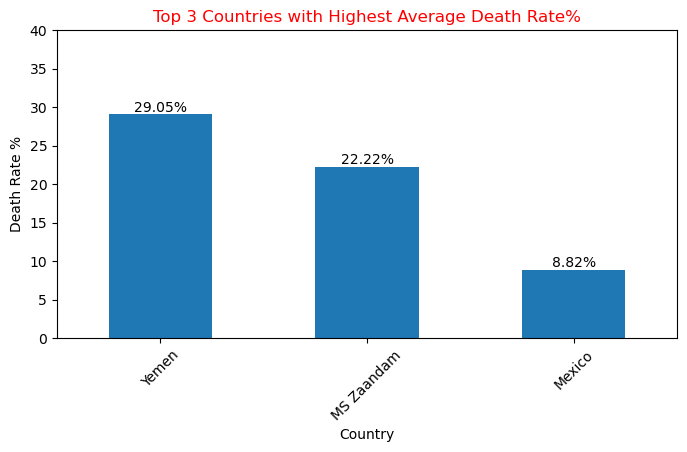

In [108]:
# Visualization [Bar Plot]
ax = top_3['DeathRate'].plot(kind = 'bar' , figsize = (8,4))
ax.set_title('Top 3 Countries with Highest Average Death Rate%' , color = 'red')
ax.set_xlabel('Country')
ax.set_ylabel('Death Rate %')
ax.bar_label(ax.containers[0] , fmt = '%.2f%%')
plt.xticks(rotation = 45)
plt.ylim(0,40)
plt.show()

> **Insight:** Some smaller or conflict-affected nations appear at the top of this list, underscoring the testing-capacity caveat above. The pattern also reflects that early in 2020, most countries were only testing the severely ill — which mechanically produced higher death rates before mass testing began.

In [109]:
# 8.2. Using the merged dataset, compare the total number of recoveries to the total number 
# of deaths in South Africa.What can this tell us about the outcomes of COVID-19 cases in the country?

df = monthly_sum_trends.copy()
total_recoveries = df[df['Country/Region'] == 'South Africa']['Recovered'].sum()
total_recoveries

1554184

---
## 12. South Africa — Recoveries vs Deaths <a id='section12'></a>

South Africa was the hardest-hit country on the African continent through most of 2020. We compare total recoveries against total deaths to get a broad picture of case outcomes.

In [110]:
total_deaths = df[df['Country/Region'] == 'South Africa']['Deaths'].sum()
total_deaths

56363

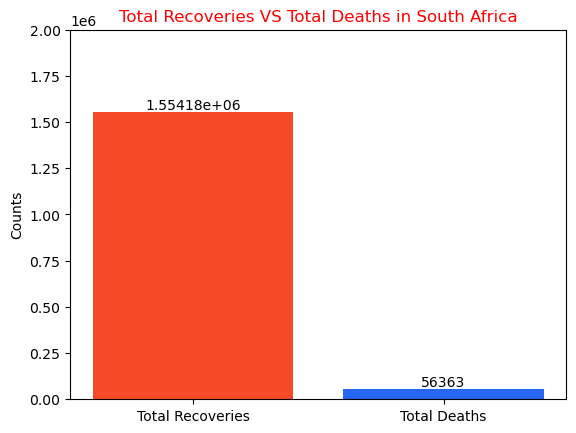

In [119]:
# Visualizations [Bar Plot]
bars = plt.bar(['Total Recoveries' , 'Total Deaths'],[total_recoveries , total_deaths], 
              color = ['#F54927','#2765F5'])
plt.title('Total Recoveries VS Total Deaths in South Africa' , color = 'red')
plt.ylabel('Counts')
plt.bar_label(bars)
plt.ylim(0,2000000)
plt.show()

> **Insight:** Recoveries vastly outnumbered deaths in South Africa — a broadly positive outcome. This likely reflects the country's comparatively young population median age and the ability of its healthcare system to manage the majority of reported cases, though rural under-reporting of deaths may partially flatter the ratio.

In [120]:
# 8.3. Analyze the ratio of recoveries to confirmed cases for the United States 
# on a monthly basis from March 2020 to May 2021. Which month experienced the 
# highest recovery ratio, and what could  be the potential reasons?

us_data = monthly_sum_trends.copy() # Shallow Copy
us_data = us_data[us_data['Country/Region'] == 'US'].sort_values('YearMonth').set_index('YearMonth')
us_data

,Country/Region,Confirmed,Deaths,Recovered
YearMonth,,,,
2020-01,US,7,0,0
2020-02,US,17,1,7
2020-03,US,192276,5369,7017
2020-04,US,888719,60865,146923
2020-05,US,717698,41605,293257
2020-06,US,843456,19767,275873
2020-07,US,1925246,26550,717529
2020-08,US,1459475,29661,746665
2020-09,US,1208533,23399,655863


---
## 13. Recovery Ratios — United States vs India <a id='section13'></a>

Recovery ratio = monthly recoveries / monthly confirmed cases. Values above 1.0 are possible when backlogs of older recoveries are reported together in a single month. We track this metric for both countries from March 2020 to May 2021 to compare how their recovery trajectories differed.

In [122]:
recovery_ratio_us = (
    us_data['Recovered'] / us_data['Confirmed']
)
recovery_ratio_us = recovery_ratio_us.loc['2020-03' : '2021-05']
recovery_ratio_us

YearMonth
2020-03    0.036494
2020-04    0.165320
2020-05    0.408608
2020-06    0.327075
2020-07    0.372695
2020-08    0.511598
2020-09    0.542693
2020-10    0.399852
2020-11    0.341204
2020-12    0.179150
2021-01    0.000000
2021-02    0.000000
2021-03    0.000000
2021-04    0.000000
2021-05    0.000000
Freq: M, dtype: float64

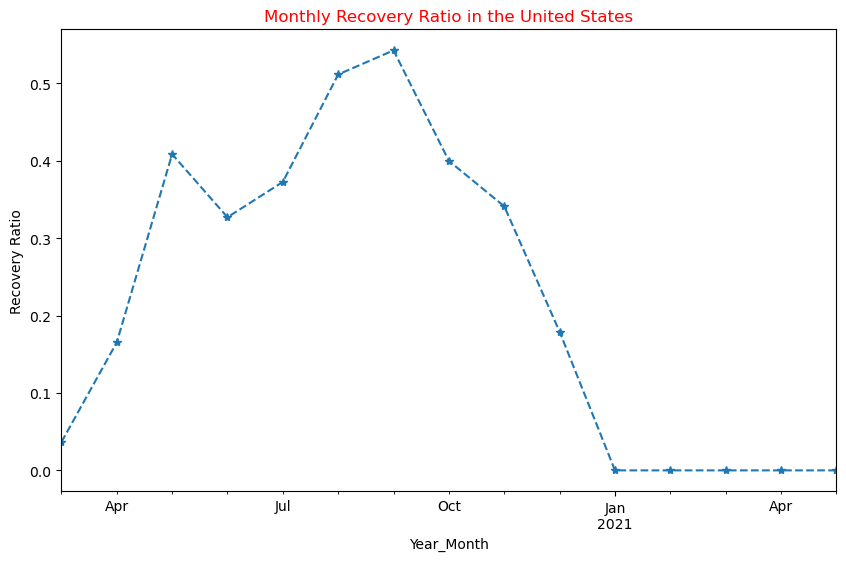

In [123]:
# Plotting the recovery_ratio using line_plot
fig , ax = plt.subplots(figsize = (10,6))
recovery_ratio_us.plot(kind = 'line' , marker = '*' , linestyle = '--' )
ax.set_title('Monthly Recovery Ratio in the United States' , color = 'red')
ax.set_xlabel('Year_Month')
ax.set_ylabel('Recovery Ratio')
plt.show()

In [124]:
# Let's explore for India as well
india_data = monthly_sum_trends.copy() # Shallow Copy
india_data = india_data[india_data['Country/Region'] == 'India'].sort_values('YearMonth').set_index('YearMonth')
india_data

,Country/Region,Confirmed,Deaths,Recovered
YearMonth,,,,
2020-01,India,1,0,0
2020-02,India,2,0,3
2020-03,India,1394,36,120
2020-04,India,33466,1119,8945
2020-05,India,155746,4254,82784
2020-06,India,394872,11992,256060
2020-07,India,1110507,19111,746462
2020-08,India,1995178,28777,1745508
2020-09,India,2621418,33390,2433319


In [125]:
recovery_ratio_india = (
    india_data['Recovered'] / india_data['Confirmed']
)
recovery_ratio_india = recovery_ratio_india.loc['2020-03' : '2021-05']
recovery_ratio_india

YearMonth
2020-03    0.086083
2020-04    0.267286
2020-05    0.531532
2020-06    0.648463
2020-07    0.672181
2020-08    0.874863
2020-09    0.928245
2020-10    1.185314
2020-11    1.093331
2020-12    1.207535
2021-01    1.170627
2021-02    0.991084
2021-03    0.620350
2021-04    0.606300
2021-05    1.119141
Freq: M, dtype: float64

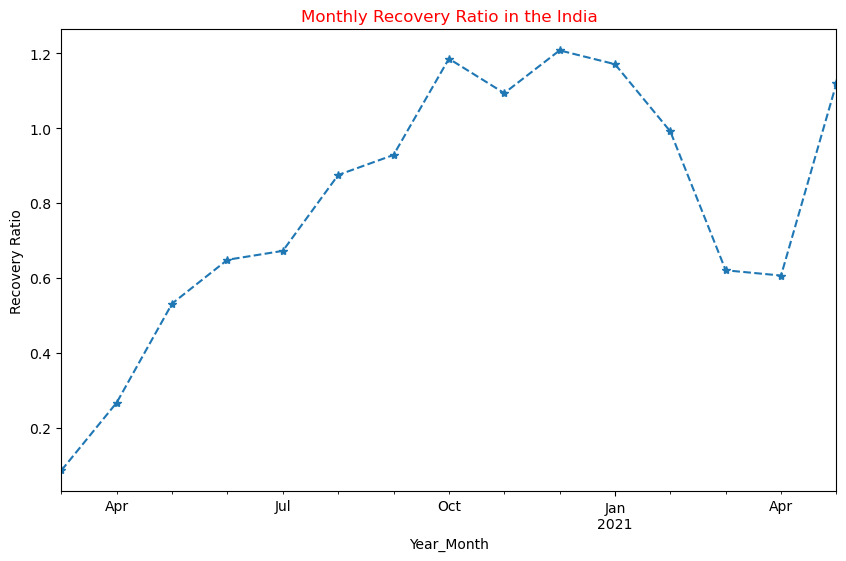

In [127]:
# Plotting the recovery_ratio using line_plot
fig , ax = plt.subplots(figsize = (10,6))
recovery_ratio_india.plot(kind = 'line' , marker = '*' , linestyle = '--' )
ax.set_title('Monthly Recovery Ratio in the India' , color = 'red')
ax.set_xlabel('Year_Month')
ax.set_ylabel('Recovery Ratio')
plt.show()

As the graph suggest recovery rates peaked around December 2020 and there was sudden drops in the rate from Jan 2021 which was result of the second 
wave of the virus.

As we compare recovery ratio between United States and India we can observe that between the period of Apr 2020 and Jan 2021 there is a significant gap between the recovery rate  which suggest that India took the virus seriously and took more precautions than US where the peak recovery rate was 0.542693 compared to india where it reached up to 1.207535.

---
## 14. Key Findings & Conclusions <a id='section14'></a>

After analysing COVID-19 data across 180+ countries from January 2020 to May 2021, the following patterns stand out:

### 1. The US, India, and Brazil dominated global case counts.
The United States led throughout the entire period. India surged dramatically in early 2021 due to the Delta variant second wave. Brazil experienced a persistently high and uncontrolled outbreak throughout both years.

### 2. China contained its outbreak faster than any other major nation.
Hubei province accounted for nearly all of China's cases, but its curve flattened sharply after March 2020 — one of the most dramatic national containment stories of the pandemic.

### 3. European second waves were synchronised.
Germany, France, and Italy all hit their worst daily surge in October–November 2020. This alignment across three separate countries suggests the second wave had shared drivers — likely autumn social behaviour and cross-border movement within the Schengen Area.

### 4. Death rates reflected testing capacity as much as healthcare quality.
Countries with limited testing showed inflated death rates because mild cases went undetected. Quebec, Canada, stood out for its high provincial death rate — largely due to long-term care home outbreaks in the first wave.

### 5. India's recovery ratio exceeded the US throughout most of 2020.
The gap suggests India reported recoveries more systematically during its first wave, or that its younger median population age led to faster clinical resolution compared to the US.

### 6. South Africa's recoveries vastly exceeded deaths.
Despite being the continent's hardest-hit country, South Africa's outcome ratio remained broadly positive — reflecting a young population and a healthcare system that managed to treat the majority of reported cases.

---

*Dataset: Johns Hopkins University CSSE COVID-19 Data Repository.*  
*Tools: Python 3, Pandas, NumPy, Matplotlib.*  
*GitHub: [SuryanshChaurasia/PythonProject](https://github.com/SuryanshChaurasia/PythonProject.git)*